In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import joblib
from sklearn.ensemble import RandomForestClassifier 

In [2]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)


In [5]:
df = pd.read_csv("Employeedata.csv")

In [6]:
print("--- Dataset Information ---")
df.info()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

In [7]:
print("\n--- Summary Statistics for Numerical Features ---")
print(df.describe())


--- Summary Statistics for Numerical Features ---
               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156  

In [8]:
# Check the unique values in categorical columns
print("\n--- Unique Values in Categorical Features ---")
for column in df.select_dtypes(include='object').columns:
    print(f"'{column}': {df[column].unique()}")
    print(f"Number of unique values: {df[column].nunique()}\n")


--- Unique Values in Categorical Features ---
'Attrition': ['Yes' 'No']
Number of unique values: 2

'BusinessTravel': ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Number of unique values: 3

'Department': ['Sales' 'Research & Development' 'Human Resources']
Number of unique values: 3

'EducationField': ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Number of unique values: 6

'Gender': ['Female' 'Male']
Number of unique values: 2

'JobRole': ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Number of unique values: 9

'MaritalStatus': ['Single' 'Married' 'Divorced']
Number of unique values: 3

'Over18': ['Y']
Number of unique values: 1

'OverTime': ['Yes' 'No']
Number of unique values: 2



--- Attrition Distribution ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64


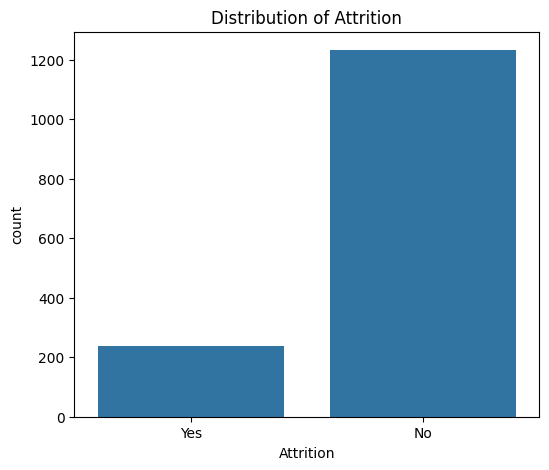

In [9]:
# 2. Attrition Distribution Analysis
print("--- Attrition Distribution ---")
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Attrition')
plt.title('Distribution of Attrition')
plt.show()


--- Numerical Feature Analysis vs. Attrition ---


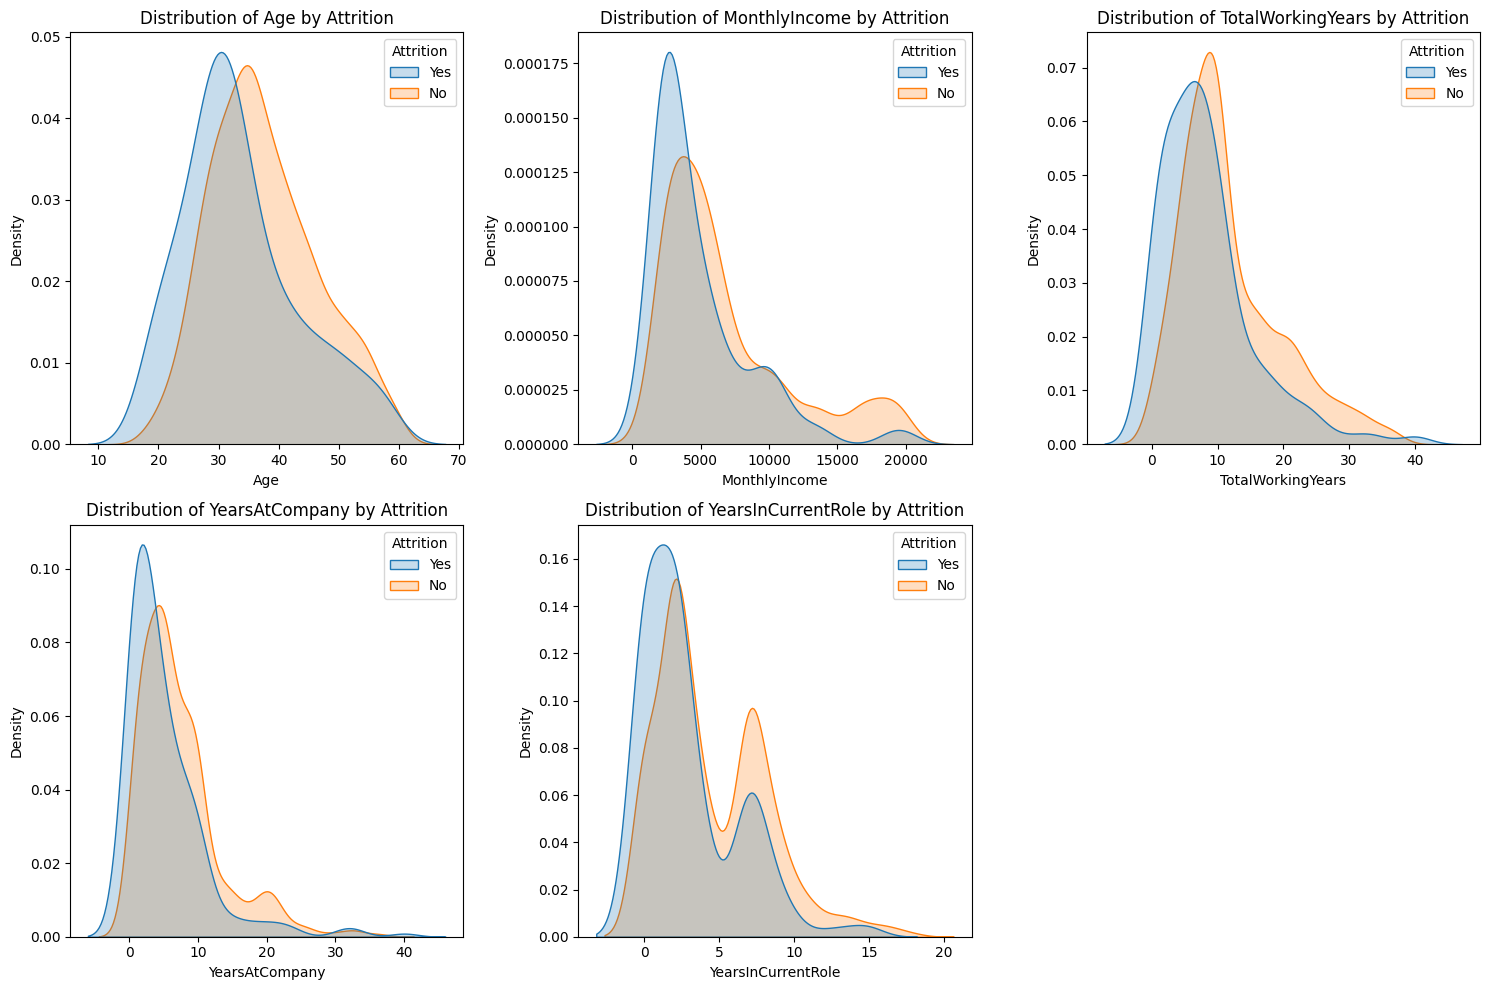

In [10]:
# 3. Bivariate Analysis with Attrition
# Analyze numerical features against attrition
numerical_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole']

print("\n--- Numerical Feature Analysis vs. Attrition ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(data=df, x=col, hue='Attrition', fill=True, common_norm=False)
    plt.title(f'Distribution of {col} by Attrition')
    plt.xlabel(col)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()


--- Categorical Feature Analysis vs. Attrition ---


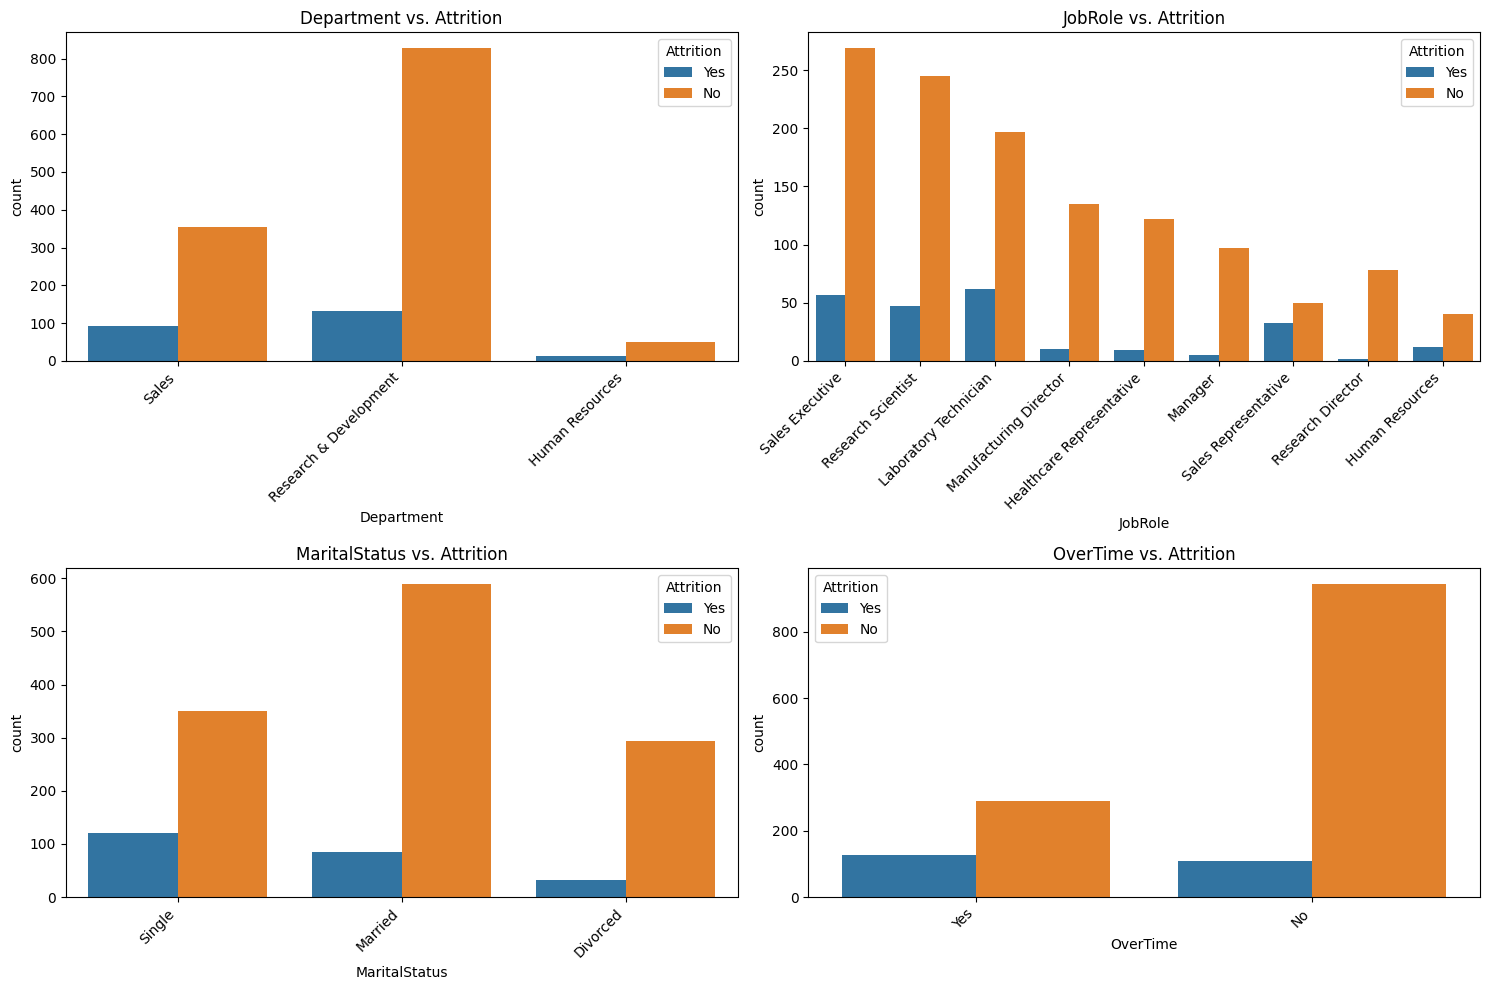

In [11]:
# Analyze categorical features against attrition
categorical_cols = ['Department', 'JobRole', 'MaritalStatus', 'OverTime']

print("\n--- Categorical Feature Analysis vs. Attrition ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=df, x=col, hue='Attrition')
    plt.title(f'{col} vs. Attrition')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
plt.show()


--- Job Satisfaction vs. Attrition ---


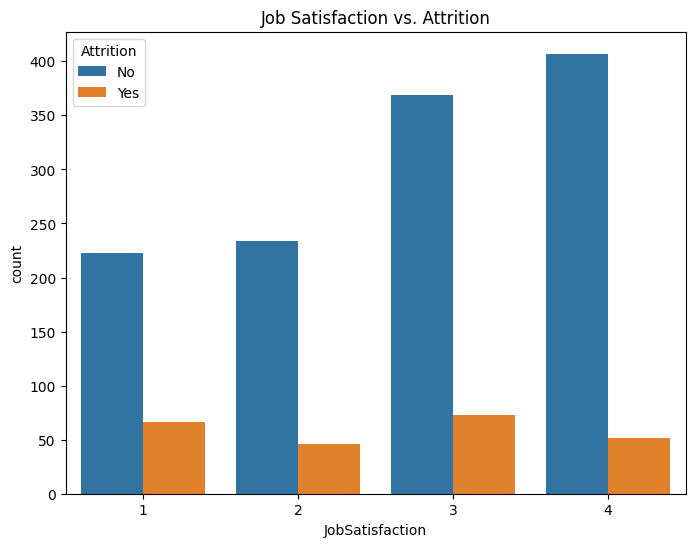

In [12]:
# Analyze JobSatisfaction and Attrition
print("\n--- Job Satisfaction vs. Attrition ---")
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Job Satisfaction vs. Attrition')
plt.show()

In [13]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18'])

In [14]:
# 2. Encode Categorical Variables
# The 'Attrition' column needs to be converted to a binary numeric format (0 and 1).
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [15]:
# Identify categorical columns to be one-hot encoded
categorical_cols = df.select_dtypes(include=['object']).columns

In [16]:
# Apply one-hot encoding to convert categorical features into a format suitable for the model
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [17]:

# Define features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [18]:
# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# 4. Create a Pipeline for Preprocessing and Modeling
# Using a pipeline ensures that preprocessing steps (like scaling and SMOTE) are
# applied consistently and correctly to the training and test data.
# The StandardScaler should be applied to the numerical columns. SMOTE should only be applied
# after the data has been split into training and test sets to prevent data leakage.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('random_forest', RandomForestClassifier(random_state=42))
])

In [20]:
# 5. Train the Model
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,100


In [21]:
# 6. Evaluate the Model
y_pred = pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       247
           1       0.43      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.65      0.58      0.59       294
weighted avg       0.79      0.83      0.80       294



In [22]:
# 7. Evaluate the Model on the Training Dataset
y_train_pred = pipeline.predict(X_train)
print("Classification Report on Training Data:")
print(classification_report(y_train, y_train_pred))

Classification Report on Training Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [23]:
# 7. Save the trained pipeline for future use
joblib.dump(pipeline, 'lr_model_pipeline.pkl')
joblib.dump(X.columns.tolist(), 'Training_columns.pkl')

['Training_columns.pkl']